In [ ]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt


from pansharpening import PANDataset
from alg2 import PANTVCB
from torchvision import transforms
from math import sqrt

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
#Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 128

    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [ ]:
val_transform = transforms.Compose([transforms.CenterCrop(crop_size)]) # Transforms a the input data to torch tensors
dataset = PANDataset(root_dir=data_path, split='train' ,transform=val_transform,normalize= True,scale=2,sigma=0.1,device='cpu', size=crop_size)

In [4]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [5]:
X.shape

torch.Size([1, 31, 128, 128])

In [6]:
# Matrice de transformation
Y_H = dataset.simule_low_hsi(X)  
Y_M = dataset.get_panchromatic(X)
R = dataset.spectral(X)


In [7]:
Y_H.shape

torch.Size([1, 31, 64, 64])

In [8]:
Y_M.shape

torch.Size([1, 1, 128, 128])

In [9]:
R.shape

torch.Size([1, 31])

In [10]:
# Calcul de l'adjoint
adjoint = dataset.simule_low_hsi_adjoint(Y_H)

# Test d'adjointitude
y = torch.randn_like(Y_H)
dot1 = torch.sum(y * dataset.simule_low_hsi(X))
dot2 = torch.sum(dataset.simule_low_hsi_adjoint(y) * X)
print(f"Test adjoint: {dot1.item():.6f} ≈ {dot2.item():.6f}")

Test adjoint: -22.934940 ≈ -22.934933


In [11]:
params = {
    'max_iter': 100,         # niters → max_iter (nom attendu par TVPrior)
    'lmbda': 1e-2,          # paramètre supplémentaire
    'theta': 1 ,            # paramètre de régularisation
    'sigma': 2,                  # sigma = gain (gain=2)   
    'tau': 0.99/2              # tau = 0.99 / gain (calculé)             
}


In [12]:
solver_cb = PANTVCB(
    A=dataset.simule_low_hsi,
    Aadj=dataset.simule_low_hsi_adjoint,
    max_iter=100,
    lmbda=11e-3,
    lmbda_m=2,
    tol=1e-7,
    scale=dataset.scale,
    verbose=True,
    params=params
)

In [14]:
U_cb, costs_gp = solver_cb(Y_H, Y_M,R)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------
0     | 5.405e+02    | 4.506e+02    | 8.864e+01    | 6.243e+00    | 9.815e-03   
10    | 5.079e+02    | 4.233e+02    | 8.314e+01    | 6.646e+00    | 8.653e-03   
20    | 4.773e+02    | 3.978e+02    | 7.799e+01    | 7.057e+00    | 7.712e-03   
30    | 4.486e+02    | 3.739e+02    | 7.319e+01    | 7.462e+00    | 6.934e-03   
40    | 4.218e+02    | 3.515e+02    | 6.871e+01    | 7.856e+00    | 6.279e-03   
50    | 3.967e+02    | 3.305e+02    | 6.453e+01    | 8.236e+00    | 5.721e-03   
60    | 3.732e+02    | 3.108e+02    | 6.061e+01    | 8.602e+00    | 5.240e-03   
70    | 3.512e+02    | 2.923e+02    | 5.696e+01    | 8.953e+00    | 4.820e-03   
80    | 3.305e+02    | 2.750e+02    | 5.355e+01    | 9.290e+00    | 4.452e-03   
90    | 3.112e+02    | 2.588e+02    | 5.036e+01    | 9.613e+00    | 4.127e-03   
99

In [15]:
U_cb.shape

torch.Size([1, 31, 128, 128])

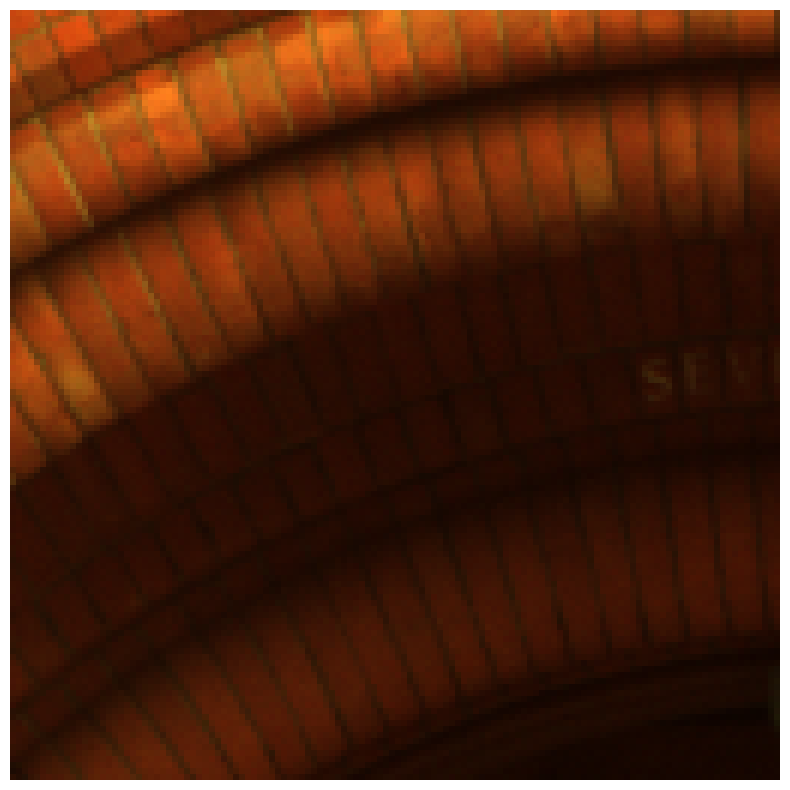

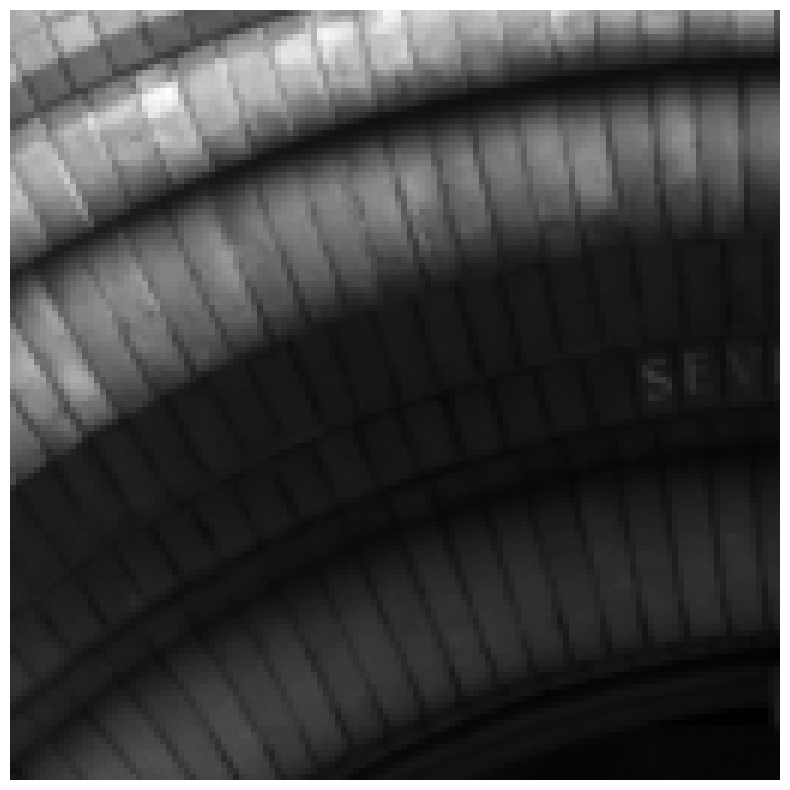

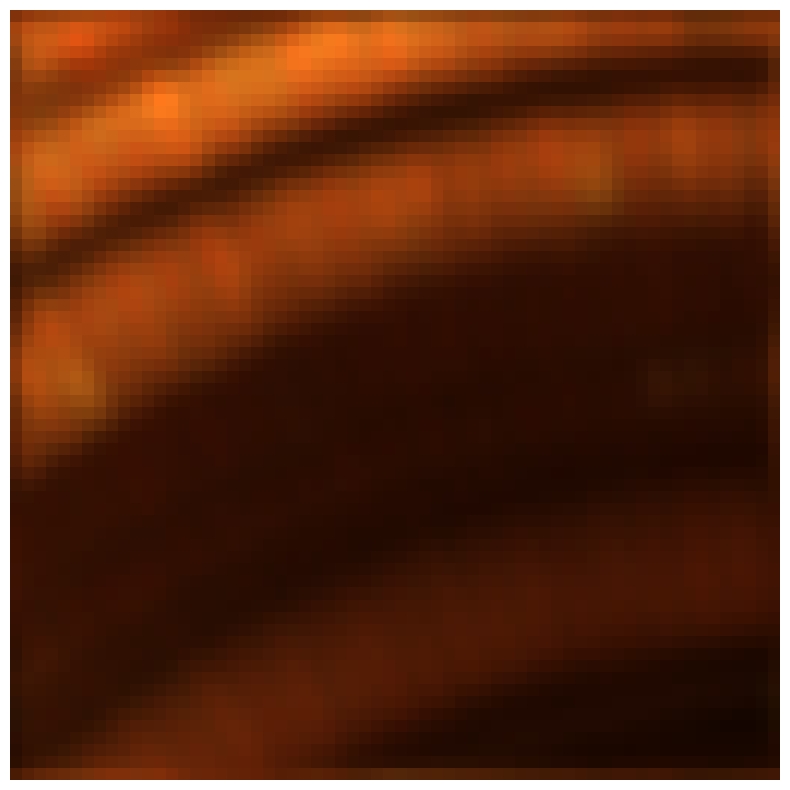

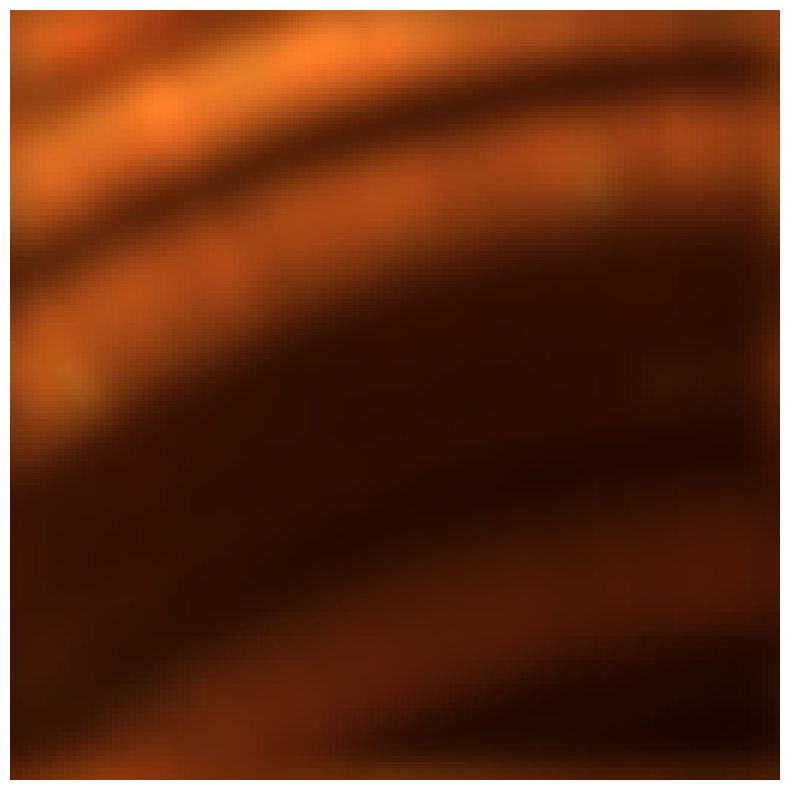

In [16]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_cb[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (100,), cout_total 100


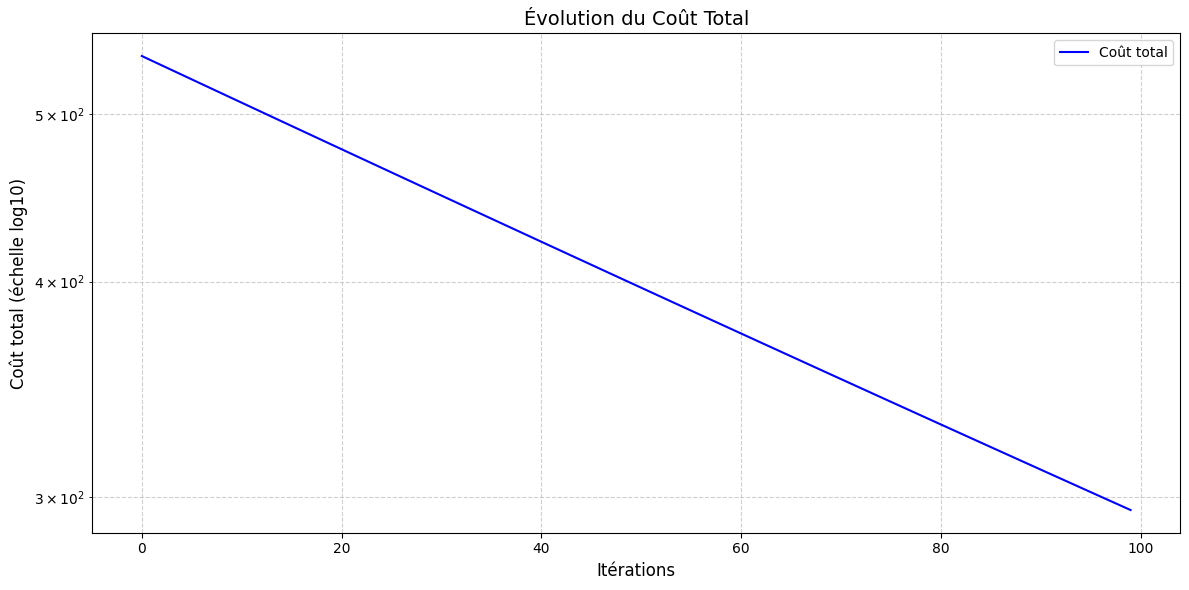

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()